# Quora Duplicate Question Detection

## Data Preparation and Exploratory Data Analysis

## Project Setup and Imports

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\ML\quora-duplicate-question-detection


In [15]:
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from src.config import (
    train_file,
    test_file,
    tfidf_save_path,
    processed_train_file,
    processed_test_file,
)
from src import preprocessing as prep
import matplotlib.pyplot as plt
import pickle

In [4]:
RANDOMSEED = 42

In [5]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

## Data Loading

In [6]:
df = pd.read_csv(train_file)
pd.set_option("display.max_colwidth", None)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
1,196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
3,266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?,1


In [7]:
df_test = pd.read_csv(test_file)
df_test.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,305985,429434,429435,Why is beef banned in India and not pork as well?,Is beef banned in india?,0
1,5193,10230,10231,At what valuation did Homejoy raise money in December of 2013?,"Should a wealthy founder self-fund his second startup then raise money at high valuation after getting traction, or raise money at low valuation before any traction?",0
2,123326,199422,199423,How do we judge?,How do I judge my love?,0
3,368557,327674,498931,Are Adderall and meth the same?,Are concerta and meth test the same?,0
4,369226,499645,499646,"If you had internet access to only one site for the rest of your life, which site would you pick?",Why is there .co.uk for British internet sites but only .fr for French ones?,0


## Exploratory Data Analysis

In [8]:
df.shape

(323432, 6)

In [ ]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df_test.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [11]:
df[df["question1"].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
31456,363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English name is most suitable for me considering the pronounciation of my Chinese name?,0


In [12]:
df[df["question2"].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
58432,201841,303951,174364,How can I create an Android app?,NaN,0
210927,105780,174363,174364,How can I develop android app?,NaN,0


**Dropping entries with missing values**

In [12]:
df.dropna(subset=["question1", "question2"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [13]:
df_test.duplicated().sum()

np.int64(0)

In [15]:
((df["question1"].str.strip() == "") |
 (df["question2"].str.strip() == "")).sum()

np.int64(0)

In [14]:
((df_test["question1"].str.strip() == "") |
 (df_test["question2"].str.strip() == "")).sum()

np.int64(0)

In [19]:
print("Train:")
print("Rows:", len(df))
print("ID unique:", df["id"].is_unique)
print("Missing ID:", df["id"].isna().sum())

print("\nTest:")
print("Rows:", len(df_test))
print("ID unique:", df_test["id"].is_unique)
print("Missing ID:", df_test["id"].isna().sum())

Train:
Rows: 323429
ID unique: True
Missing ID: 0

Test:
Rows: 80858
ID unique: True
Missing ID: 0


No fully duplicated rows or empty question strings were found.

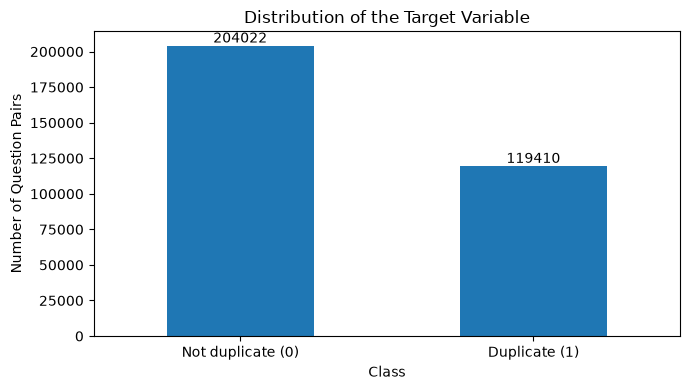

In [17]:
target_distribution = (
    df["is_duplicate"]
    .value_counts()
    .sort_index()
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("Distribution of the Target Variable")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Question Pairs")
ax.set_xticklabels(
    ["Not duplicate (0)", "Duplicate (1)"],
    rotation=0,
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The target variable is moderately imbalanced: non-duplicate question pairs
represent the majority class, while duplicate pairs account for approximately
37% of the training dataset.

In [18]:
questions = pd.concat([df["question1"], df["question2"]], ignore_index=True)
all_question_lengths = questions.str.len()
all_question_lengths.describe()

count    646861.000000
mean         59.827510
std          31.968483
min           1.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1169.000000
dtype: float64

In [19]:
all_question_lengths.quantile([0.95, 0.99, 0.999])

0.950    125.00
0.990    156.00
0.999    270.14
dtype: float64

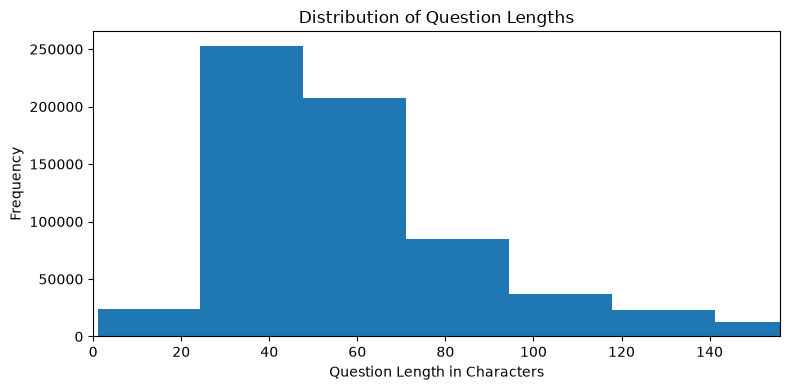

In [20]:
all_question_lengths.plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.title("Distribution of Question Lengths")
plt.xlabel("Question Length in Characters")
plt.ylabel("Frequency")
plt.xlim(0, all_question_lengths.quantile(0.99))
plt.tight_layout()
plt.show()

**The distribution is right-skewed: most questions are relatively short: the mean length is about 60 characters,
99% of questions are shorter than 156 characters, and 99.9% are shorter than
approximately 270 characters. The x-axis is limited to
the 99th percentile to make the main part of the distribution easier to see.**

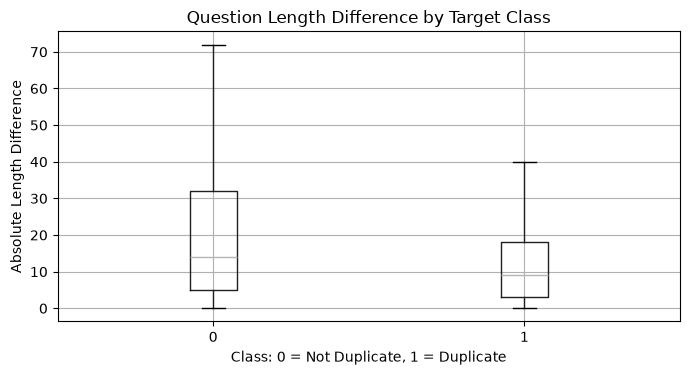

In [21]:
length_comparison = pd.DataFrame(
    {
        "is_duplicate": df["is_duplicate"],
        "length_difference": (
            df["question1"].str.len()
            - df["question2"].str.len()
        ).abs(),
    }
)

length_comparison.boxplot(
    column="length_difference",
    by="is_duplicate",
    figsize=(7, 4),
    showfliers=False,
)

plt.title("Question Length Difference by Target Class")
plt.suptitle("")
plt.xlabel("Class: 0 = Not Duplicate, 1 = Duplicate")
plt.ylabel("Absolute Length Difference")
plt.tight_layout()
plt.show()

Duplicate question pairs generally have a smaller absolute difference in
question length. Their median length difference and interquartile range are
lower than those of non-duplicate pairs.
It may serve as a useful feature when combined with other lexical and similarity
features in a boosting model.

In [17]:
print("Number of unique questions:", questions.nunique())

Number of unique questions: 449361


In [18]:
print("Number of all questions: ", questions.shape[0])

Number of all questions:  646858


## Data Split

In [ ]:
X = df.drop(columns=["is_duplicate"])
y = df['is_duplicate']

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify = y,
                                                  random_state=RANDOMSEED)

In [24]:
df["split"] = pd.NA

train_ids = X_train["id"]
valid_ids = X_valid["id"]

df.loc[df["id"].isin(train_ids), "split"] = "train"
df.loc[df["id"].isin(valid_ids), "split"] = "valid"

In [25]:
assert df["split"].notna().all()
assert df["id"].is_unique

print(df["split"].value_counts())
print()

print(
    df.groupby("split")["is_duplicate"]
    .value_counts(normalize=True)
    .unstack()
)

split
train    258743
valid     64686
Name: count, dtype: int64

is_duplicate         0         1
split                           
train         0.630800  0.369200
valid         0.630801  0.369199


In [23]:
X_test = df_test.drop(columns=["is_duplicate"])
y_test = df_test['is_duplicate']

## Text Preprocessing and TF-IDF

### TF-IDF text map creation

The cells below create and save the processed text mapping.
They should only be executed when the saved mapping does not exist
or when the preprocessing logic has changed.

In [29]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

In [38]:
unique_questions = prep.collect_unique_questions(
    X_train,
    X_valid,
    X_test
)

In [39]:
basic_tfidf_texts = unique_questions.apply(
    prep.prepare_text_for_tfidf
)

In [ ]:
processed_tfidf_texts = []

docs = nlp.pipe(
    basic_tfidf_texts,
    batch_size=1000,
    n_process=1
)

for doc in tqdm(
    docs,
    total=len(basic_tfidf_texts)
):
    processed_tfidf_texts.append(
        prep.process_spacy_doc(doc)
    )

In [ ]:
tfidf_text_map = dict(
    zip(unique_questions, processed_tfidf_texts)
)

print(f"Processed questions: {len(tfidf_text_map):,}")

Processed questions: 537,359


In [ ]:
with open(tfidf_save_path, "wb") as f:
    pickle.dump(tfidf_text_map, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved to: {tfidf_save_path}")

Saved to: /content/drive/MyDrive/ML Projects/Quora duplicates/embeddings/tfidf_text_map_v1.pkl


### Load TF-IDF texts and add them as features to datasets

In [41]:
with open(tfidf_save_path, "rb") as f:
    tfidf_text_map = pickle.load(f)

print(f"Loaded processed questions: {len(tfidf_text_map):,}")

Loaded processed questions: 537,359


In [43]:
X_train["question1_tfidf"] = (
    X_train["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_train["question2_tfidf"] = (
    X_train["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_valid["question1_tfidf"] = (
    X_valid["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_valid["question2_tfidf"] = (
    X_valid["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_test["question1_tfidf"] = (
    X_test["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_test["question2_tfidf"] = (
    X_test["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

In [44]:
text_columns = [
    "question1_tfidf",
    "question2_tfidf"
]

for column in text_columns:
    print(
        column,
        "train empty:",
        X_train[column].fillna("").str.strip().eq("").sum(),
        "val empty:",
        X_valid[column].fillna("").str.strip().eq("").sum()
    )

question1_tfidf train empty: 7 val empty: 4
question2_tfidf train empty: 4 val empty: 1


### Text normalization for manual feature engineering

Create lightly normalized versions of both questions for future handcrafted
feature engineering and boosting models.

The preprocessing converts text to lowercase, removes HTML tags and normalizes
whitespace, while preserving stop words, punctuation and numbers.

These columns are not used in the TF-IDF Logistic Regression experiment.

An initial preprocessing pipeline included stop-word removal. After inspecting the processed texts, it became clear that this step removed all informative tokens from some valid questions (e.g., "Who am I?", "How is everyone?", "Why did you give up?"), resulting in empty documents. Since interrogative words and auxiliary verbs carry important semantic information in question-pair similarity tasks, stop-word removal was excluded from the final pipeline. After this revision, only questions consisting entirely of punctuation or other non-lexical characters remained empty. These samples were retained, as TF-IDF naturally represents them as zero vectors without affecting the preprocessing pipeline.

In [ ]:
for X in [X_train, X_valid, X_test]:
    X["question1_features"] = (
        X["question1"]
        .apply(prep.prepare_text_for_features)
    )

    X["question2_features"] = (
        X["question2"]
        .apply(prep.prepare_text_for_features)
    )

## Save Preprocessed Datasets

Combine the predefined train and validation subsets, preserve the stable
original `id`, and save the processed train and test datasets in Parquet format.

In [45]:
base_columns = [
    "id",
    "qid1",
    "qid2",
    "question1",
    "question2",
]

processed_text_columns = [
    "question1_tfidf",
    "question2_tfidf",
    "question1_features",
    "question2_features",
]

processed_train = pd.concat(
    [
        X_train.assign(
            is_duplicate=y_train,
            split="train",
        ),
        X_valid.assign(
            is_duplicate=y_valid,
            split="valid",
        ),
    ],
    axis=0,
).sort_index()

processed_test = (
    X_test.assign(is_duplicate=y_test)
    .sort_index()
)

processed_train = processed_train[
    base_columns
    + ["is_duplicate", "split"]
    + processed_text_columns
].reset_index(drop=True)

processed_test = processed_test[
    base_columns
    + ["is_duplicate"]
    + processed_text_columns
].reset_index(drop=True)

In [ ]:
Path(processed_train_file).parent.mkdir(
    parents=True,
    exist_ok=True,
)

processed_train.to_parquet(
    processed_train_file,
    index=False,
)

processed_test.to_parquet(
    processed_test_file,
    index=False,
)

print("Saved train dataset:")
print(processed_train_file)

print("\nSaved test dataset:")
print(processed_test_file)